# Results Analysis

Run all three methods under the same setup, compare train/test metrics, and prepare thesis-ready figures.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import math
import matplotlib.pyplot as plt

from src.config import default_data_config, default_hyperparams
from src.data import load_mnist_3vs8
from src.init import initialize_params
from src.baselines import fit_raw_svm, fit_separate_dict_svm
from src.solver import fit_joint_pg
from src.metrics import summarize_joint_result, evaluate_joint_model

data_cfg = default_data_config()
hyper = default_hyperparams()

X_train, y_train, X_val, y_val, X_test, y_test = load_mnist_3vs8(**data_cfg.__dict__)

raw_result = fit_raw_svm(X_train, y_train, X_test, y_test, hyper)
separate_result = fit_separate_dict_svm(X_train, y_train, X_test, y_test, hyper)
init_params = initialize_params(X_train, y_train, hyper.dictionary_size, seed=hyper.random_state)
joint_result = fit_joint_pg(X_train, y_train, hyper, init_params)

joint_train_metrics = summarize_joint_result(joint_result, X_train, y_train)
joint_test_metrics = evaluate_joint_model(X_test, y_test, joint_result['params'], hyper)

comparison_rows = [
    {
        'method': 'Raw SVM',
        'train_accuracy': raw_result['metrics']['train_accuracy'],
        'test_accuracy': raw_result['metrics']['test_accuracy'],
        'train_reconstruction_error': None,
        'test_reconstruction_error': None,
        'train_code_sparsity': None,
        'test_code_sparsity': None,
    },
    {
        'method': 'Separate Dict + SVM',
        'train_accuracy': separate_result['metrics']['train_accuracy'],
        'test_accuracy': separate_result['metrics']['test_accuracy'],
        'train_reconstruction_error': separate_result['metrics']['reconstruction_error'],
        'test_reconstruction_error': None,
        'train_code_sparsity': float((abs(separate_result['codes_train']) <= 1e-10).mean()),
        'test_code_sparsity': float((abs(separate_result['codes_test']) <= 1e-10).mean()),
    },
    {
        'method': 'Joint Dict + SVM',
        'train_accuracy': joint_train_metrics['accuracy'],
        'test_accuracy': joint_test_metrics['accuracy'],
        'train_reconstruction_error': joint_train_metrics['reconstruction_error'],
        'test_reconstruction_error': joint_test_metrics['reconstruction_error'],
        'train_code_sparsity': joint_train_metrics['code_sparsity'],
        'test_code_sparsity': joint_test_metrics['code_sparsity'],
    },
]

for row in comparison_rows:
    print(row)

print('joint status:', joint_result['status'])
print('joint iterations:', len(joint_result['history']['objective']))


{'method': 'Raw SVM', 'train_accuracy': 1.0, 'test_accuracy': 0.9425, 'train_reconstruction_error': None, 'test_reconstruction_error': None, 'train_code_sparsity': None, 'test_code_sparsity': None}
{'method': 'Separate Dict + SVM', 'train_accuracy': 0.974, 'test_accuracy': 0.945, 'train_reconstruction_error': 106.53963423305966, 'test_reconstruction_error': None, 'train_code_sparsity': 0.000203125, 'test_code_sparsity': 0.0023046875}
{'method': 'Joint Dict + SVM', 'train_accuracy': 0.941, 'test_accuracy': 0.925, 'train_reconstruction_error': 106.99057747823512, 'test_reconstruction_error': 71.50548748482531, 'train_code_sparsity': 0.003140625, 'test_code_sparsity': 0.002265625}
joint status: max_iter_reached
joint iterations: 100


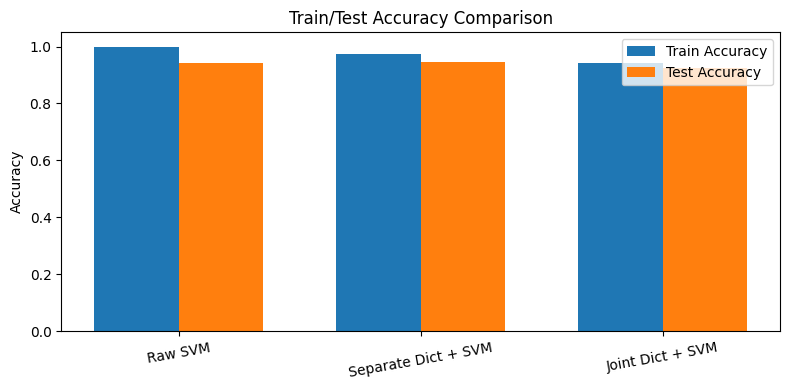

In [2]:
methods = [row['method'] for row in comparison_rows]
train_acc = [row['train_accuracy'] for row in comparison_rows]
test_acc = [row['test_accuracy'] for row in comparison_rows]

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(methods))
width = 0.35
ax.bar([i - width / 2 for i in x], train_acc, width=width, label='Train Accuracy')
ax.bar([i + width / 2 for i in x], test_acc, width=width, label='Test Accuracy')
ax.set_xticks(list(x))
ax.set_xticklabels(methods, rotation=10)
ax.set_ylim(0.0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Train/Test Accuracy Comparison')
ax.legend()
plt.tight_layout()
plt.show()

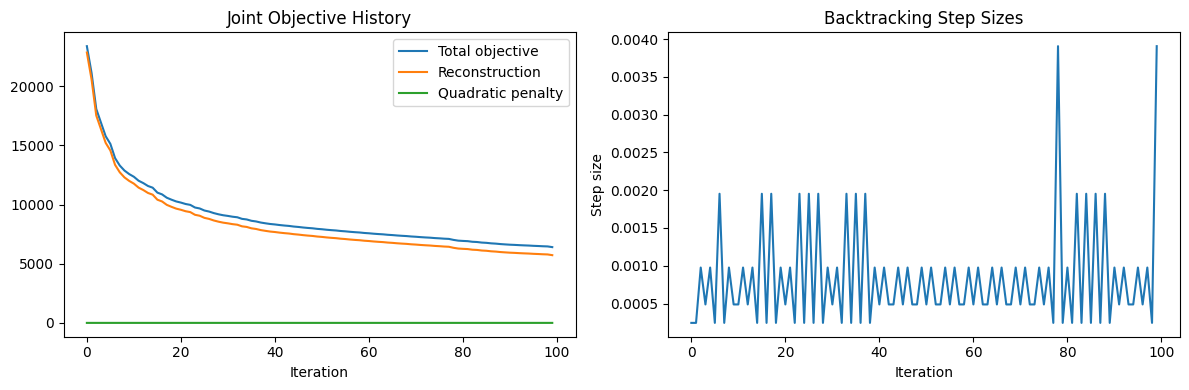

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(joint_result['history']['objective'], label='Total objective')
axes[0].plot(joint_result['history']['reconstruction'], label='Reconstruction')
axes[0].plot(joint_result['history']['quadratic_penalty'], label='Quadratic penalty')
axes[0].set_title('Joint Objective History')
axes[0].set_xlabel('Iteration')
axes[0].legend()

axes[1].plot(joint_result['history']['step_size'])
axes[1].set_title('Backtracking Step Sizes')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Step size')

plt.tight_layout()
plt.show()

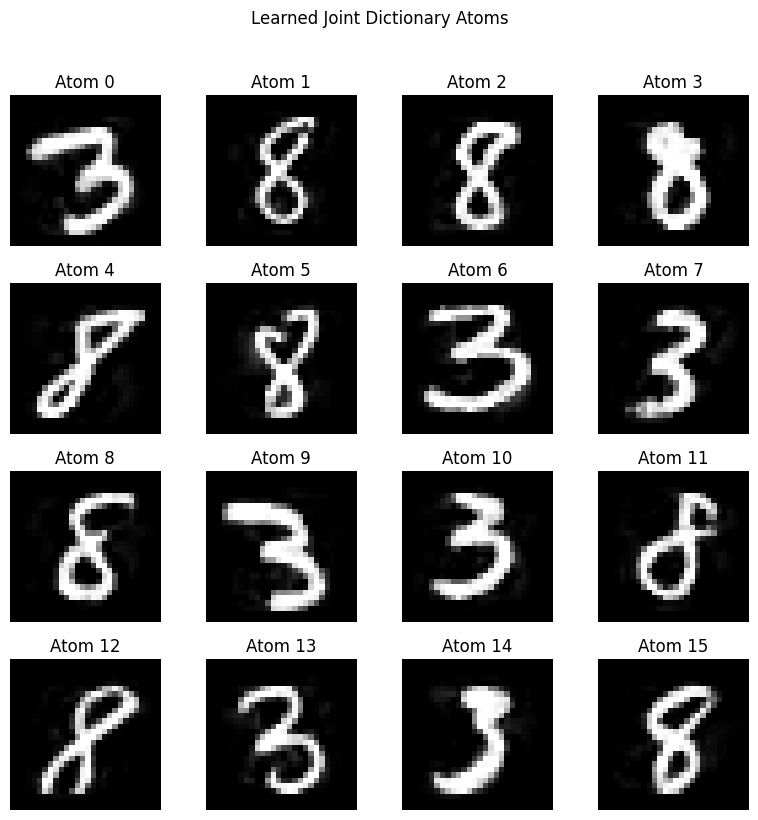

In [4]:
D = joint_result['params']['D']
num_atoms = min(16, D.shape[1])
cols = 4
rows = math.ceil(num_atoms / cols)

fig, axes = plt.subplots(rows, cols, figsize=(8, 2 * rows))
axes = axes.ravel() if hasattr(axes, 'ravel') else [axes]

for idx, ax in enumerate(axes):
    ax.axis('off')
    if idx < num_atoms:
        ax.imshow(D[:, idx].reshape(28, 28), cmap='gray')
        ax.set_title(f'Atom {idx}')

plt.suptitle('Learned Joint Dictionary Atoms', y=1.02)
plt.tight_layout()
plt.show()

## Interpretation Notes

- Compare `test_accuracy` across all three methods, not baseline test accuracy against joint train accuracy.
- The joint method evaluates the test split by fixing the learned dictionary and classifier, then inferring sparse codes for the test images.
- If the joint method is still weaker, the main suspects are hyperparameters (`mu`, `rho`, `eta`, `gamma`), dictionary size, and the fact that the current solver is only a first baseline implementation rather than a tuned final method.